In [1]:
import operator
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [4]:
class CandidateState(TypedDict):
    resume: str

    skill_feedback: str
    experience_feedback: str
    communication_feedback: str

    score: Annotated[list[int], operator.add]

    average_score : float
    decision: str

In [5]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback")

    score: int = Field(
        description="Score out of 10",
        ge=0,
        le=10
    )

In [6]:
structured_model = model.with_structured_output(
    EvaluationSchema
)

In [7]:
def evaluate_skill(state: CandidateState):
    prompt = f"""
    Evaluate the technical skill of the candidate.

    Resume:
    {state['resume']}

    Give:
    1. Feedback
    2. Score out of 10

"""

    output = structured_model.invoke(prompt)
    return {
        "skill_feedback": output.feedback,
        "score": [output.score]
    }

In [8]:
def evaluate_experience(state: CandidateState):
    prompt = f"""
    Evaluate the work experience of the candidate.

    Resume:
    {state['resume']}

    Give:
    1. Feedback
    2. Score out of 10
    """ 
    output = structured_model.invoke(prompt)

    return {
        "experience_feedback": output.feedback,
        "score": [output.score]
    }

In [9]:
def evaluate_communication(state: CandidateState):
    prompt = f"""
    Evaluate the communication ability  of the candidate
    based on the resume

    Resume:
    {state['resume']}

    Give:
    1. Feedback
    2. Score out of 10
    """

    output = structured_model.invoke(prompt)

    return {
        "communication_feedback": output.feedback,
        "score": [output.score]
    }

In [10]:
def calculate_average(state: CandidateState):
    scores = state['score']
    avg = sum(scores) / len(scores)

    return {
        "average_score": round(avg, 2)
    }

In [11]:
def make_decision(state: CandidateState):
    avg = state['average_score']

    if avg >= 8:
        decision = "Selected"
    elif avg >= 6:
        decision = "Need Futher Interview"
    else:
        decision = "Rejected"

    return {
        "decision": decision
    }

In [12]:
graph = StateGraph(CandidateState)

graph.add_node("evaluate_skill", evaluate_skill)
graph.add_node("evaluate_experience", evaluate_experience)
graph.add_node("evaluate_communication", evaluate_communication)
graph.add_node("calculate_average", calculate_average)
graph.add_node("make_decision", make_decision)

graph.add_edge(START, "evaluate_skill")
graph.add_edge(START, "evaluate_experience")
graph.add_edge(START, "evaluate_communication")

In [13]:
graph.add_edge("evaluate_skill", "calculate_average")
graph.add_edge("evaluate_experience", "calculate_average")
graph.add_edge("evaluate_communication", "calculate_average")

In [14]:
graph.add_edge("calculate_average", "make_decision")
graph.add_edge("make_decision", END)

In [15]:
workflow = graph.compile()

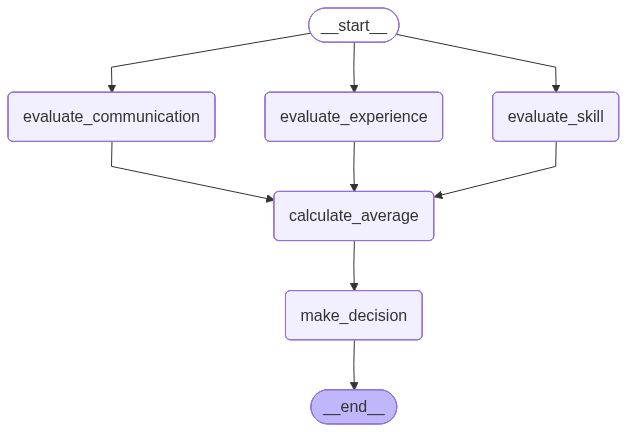

In [16]:
workflow

In [ ]:
initial_state = {
    "resume": """
    Python Developer

    Skills:
    Python
    Django
    SQL
    Machine Learning

    Experience:
    2 Years Django Developer
    Built Healthcare Management System
    """
}

result = workflow.invoke(initial_state)

print(result).

{'resume': '\n    Python Developer\n\n    Skills:\n    Python\n    Django\n    SQL\n    Machine Learning\n\n    Experience:\n    2 Years Django Developer\n    Built Healthcare Management System\n    ', 'skill_feedback': "The candidate has a strong foundation in Python and its frameworks, particularly Django. The experience in building a Healthcare Management System is impressive and demonstrates practical application of skills. However, more details about the machine learning skills and experience would be beneficial. Overall, the candidate's technical skill is good, but more information about specific accomplishments and challenges would be helpful.", 'experience_feedback': "The candidate has a strong background in Python and Django, with 2 years of experience as a Django developer. The experience in building a Healthcare Management System is impressive and relevant to the field. However, the candidate's skills in Machine Learning are not reflected in their experience, which could be 